# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

     sales   adverts  airplay  attract
0      330    10.256       43       10
1      120   985.685       28        7
2      360  1445.563       35        7
3      270  1188.193       33        7
4      220   574.513       44        5
..     ...       ...      ...      ...
195    190   910.851       26        7
196    240   888.569       14        6
197    250   800.615       34        6
198    230  1500.000       11        8
199    110   785.694       20        9

[200 rows x 4 columns]


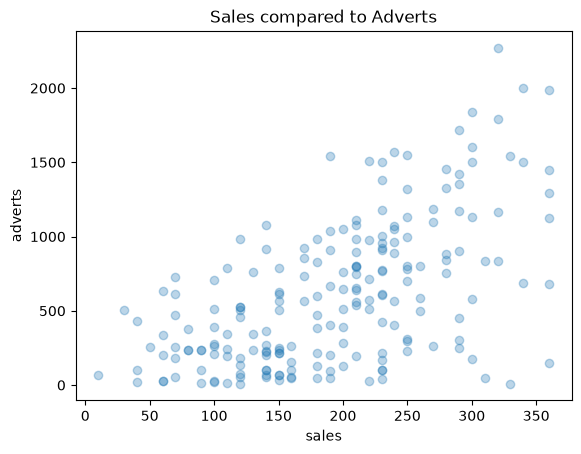

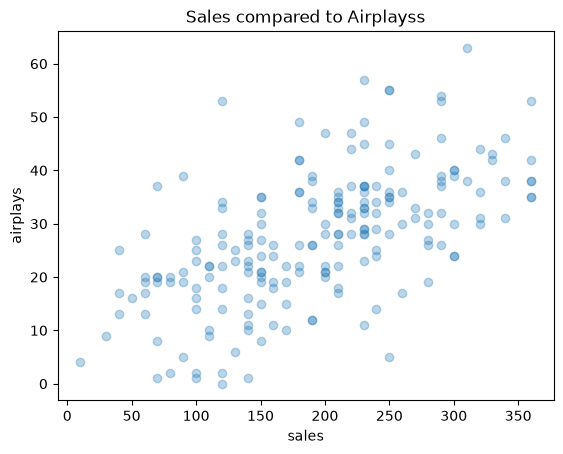

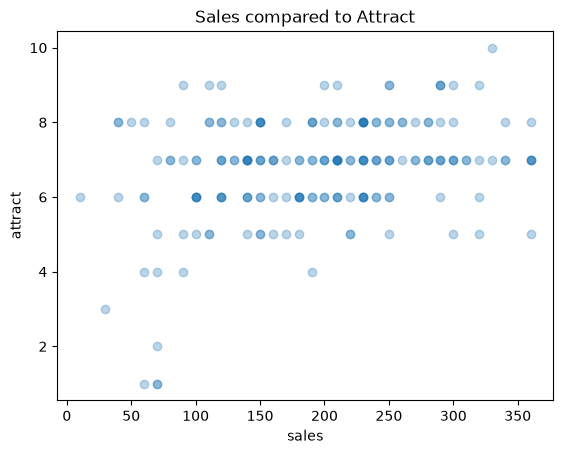

In [42]:
# Code here
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./album_sales.csv")
print(df)

plt.scatter(x=df['sales'], y = df['adverts'], alpha=0.3)
plt.title("Sales compared to Adverts")
plt.xlabel('sales')
plt.ylabel("adverts")
plt.show()


plt.scatter(x=df['sales'], y = df['airplay'], alpha=0.3)
plt.title("Sales compared to Airplayss")
plt.xlabel('sales')
plt.ylabel("airplays")
plt.show()


plt.scatter(x=df['sales'], y = df['attract'], alpha=0.3)
plt.title("Sales compared to Attract")
plt.xlabel('sales')
plt.ylabel("attract")
plt.show()



In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

Sales compared to adverts has a postive with medium ish string in correlation relationship.
Sales compared to airplays has a postive correlation with medium ish relationship.
Sales compared to attract has no correlation in the relationship.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [43]:
# Code here
x = df['adverts']
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x) # use it later for visualization

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        17:36:28   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The f-statistic of 99.59 would suggest that  it is good and very significiant. The p-value is very low so that means that this a very trustworthy linear regression model that is very unlikely to happen by chance.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [44]:
z = 135000
x = z/1000
y = 134.1399 + (0.0961 * x)

print(f"How many record sales would {z}$ get you: {y}")


How many record sales would 135000$ get you: 147.1134


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [45]:
# Code here
x = df[['adverts', 'airplay', 'attract']]
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        17:36:28   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

The better model has a r-squared value of 2 0.665 which is higher than model 1 which has a  r-squared value of 0.335 and they both have p values less than 0.05 so that proves model 2 is better.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name